# Smart Traffic Signal Optimizer
Detect and count cars per zone at an intersection using YOLOv8, then decide if the signal cycle should change.

In [1]:
# Install dependencies
!pip install ultralytics opencv-python-headless matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.1 MB/s eta 0:00:00 MB/s eta 0:00:01
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [17]:
import torch
print(torch.cuda.is_available())  # True = está a usar GPU
print(model.device) 

False
cpu


In [2]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/user/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1. Load YOLOv8 (pre-trained on COCO — already detects cars)

In [3]:
model = YOLO("yolov8n.pt")  # nano = fast. Use yolov8s.pt for better accuracy

# COCO vehicle classes
VEHICLE_CLASSES = {2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}

## 2. Define intersection zones
Each zone = one direction of traffic. Adjust `(x1, y1, x2, y2)` to your camera.

In [9]:
# Read image dimensions first
img = cv2.imread(IMAGE_PATH)
h, w = img.shape[:2]
print(f"Image size: {w}x{h}")

# Zones as % of image — adjust these ratios to your camera
ZONES = {
    "north": (int(w*0.3), 0,           int(w*0.7), int(h*0.35)),
    "south": (int(w*0.3), int(h*0.65), int(w*0.7), h),
    "east":  (int(w*0.65), int(h*0.25), w,          int(h*0.75)),
    "west":  (0,           int(h*0.25), int(w*0.35), int(h*0.75)),
}

Image size: 300x168


## 3. Detect vehicles and count per zone

In [5]:
def detect_vehicles(image_path):
    results = model(image_path, verbose=False)[0]
    vehicles = []
    for box in results.boxes:
        cls_id = int(box.cls[0])
        if cls_id in VEHICLE_CLASSES:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            vehicles.append({
                "bbox": (x1, y1, x2, y2),
                "center": ((x1 + x2) / 2, (y1 + y2) / 2),
                "class": VEHICLE_CLASSES[cls_id],
                "confidence": float(box.conf[0]),
            })
    return vehicles


def count_per_zone(vehicles, zones):
    counts = {zone: 0 for zone in zones}
    for v in vehicles:
        cx, cy = v["center"]
        for name, (x1, y1, x2, y2) in zones.items():
            if x1 <= cx <= x2 and y1 <= cy <= y2:
                counts[name] += 1
                break
    return counts

## 4. Signal decision logic
If red side has way more cars than green side → switch.

In [15]:
def should_switch_signal(zone_counts, signal_state, threshold=1):
    red_total = sum(zone_counts[z] for z in signal_state["red"])
    green_total = sum(zone_counts[z] for z in signal_state["green"])
    diff = red_total - green_total

    if red_total > 0 and green_total == 0:
        return True, f"Red has {red_total} cars, green is EMPTY → Switch now!"
    elif diff >= threshold:
        return True, f"Red ({red_total}) has {diff} more than green ({green_total}) → Switch"
    else:
        return False, f"Balanced — Red: {red_total}, Green: {green_total} → Keep cycle"

## 5. Visualize

In [ ]:
def visualize(image_path, vehicles, zone_counts, signal_state, decision):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(16, 12))
    ax.imshow(img)

    # Draw zones
    for name, (x1, y1, x2, y2) in ZONES.items():
        color = "lime" if name in signal_state["green"] else "red"
        rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                         linewidth=2, edgecolor=color, facecolor=color, alpha=0.15)
        ax.add_patch(rect)
        ax.text(x1 + 5, y1 + 20, f"{name.upper()}: {zone_counts[name]} cars",
                color="white", fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round", facecolor=color, alpha=0.7))

    # Draw detections
    for v in vehicles:
        bx1, by1, bx2, by2 = v["bbox"]
        rect = Rectangle((bx1, by1), bx2 - bx1, by2 - by1,
                         linewidth=1.5, edgecolor="cyan", facecolor="none")
        ax.add_patch(rect)
        ax.text(bx1, by1 - 5, f"{v['class']} {v['confidence']:.0%}", color="cyan", fontsize=7)

    should_switch, reason = decision
    banner = "SWITCH SIGNAL" if should_switch else "KEEP CURRENT"
    color = "#ff4444" if should_switch else "#44aa44"
    ax.set_title(f"{banner}\n{reason}", fontsize=13, color=color, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 6. Run it!
Replace `IMAGE_PATH` with your intersection image or video frame.

Detected 13 vehicles
Per zone: {'north': 5, 'south': 1, 'east': 2, 'west': 1}
Decision: Balanced — Red: 3, Green: 6 → Keep cycle


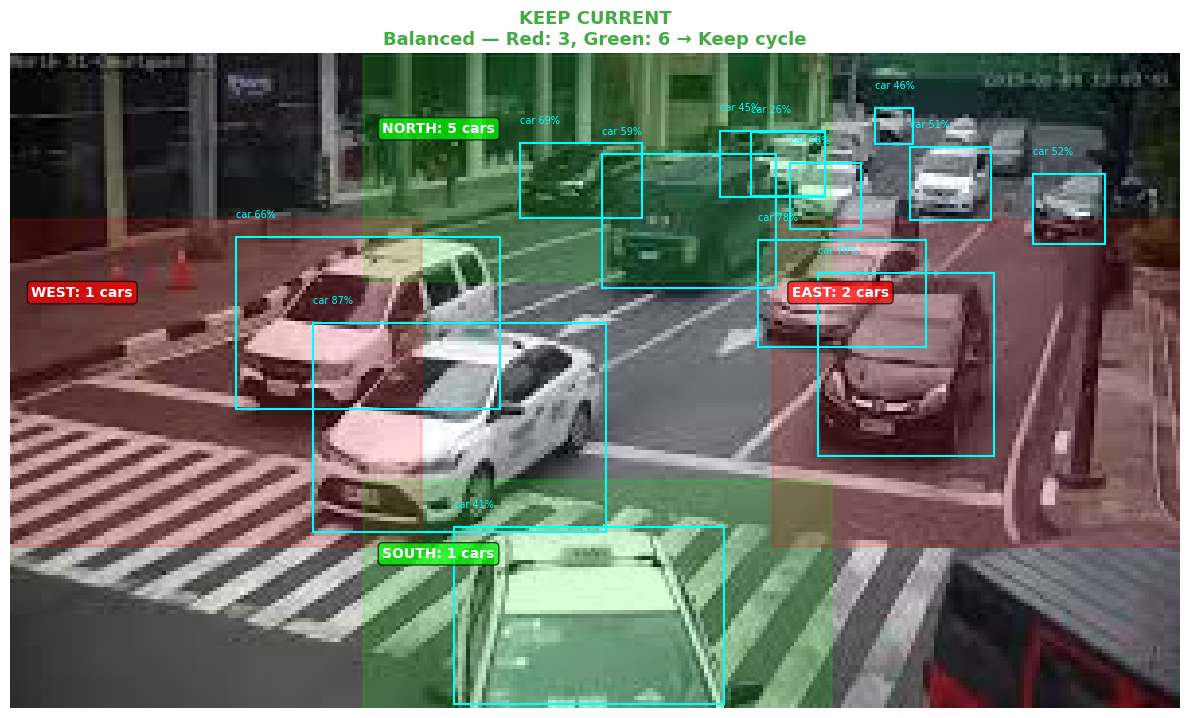

In [16]:
IMAGE_PATH = "images.jpeg"  # <-- change this

vehicles = detect_vehicles(IMAGE_PATH)
print(f"Detected {len(vehicles)} vehicles")

zone_counts = count_per_zone(vehicles, ZONES)
print(f"Per zone: {zone_counts}")

decision = should_switch_signal(zone_counts, signal_state)
print(f"Decision: {decision[1]}")

visualize(IMAGE_PATH, vehicles, zone_counts, signal_state, decision)

## 7. (Bonus) Process video frame by frame

In [ ]:
def process_video(video_path, sample_every=30):
    cap = cv2.VideoCapture(video_path)
    history = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % sample_every == 0:
            cv2.imwrite("_temp.jpg", frame)
            vehicles = detect_vehicles("_temp.jpg")
            counts = count_per_zone(vehicles, ZONES)
            switch, reason = should_switch_signal(counts, signal_state)
            history.append({"frame": frame_idx, "counts": counts, "switch": switch})
            print(f"Frame {frame_idx}: {counts} -> {'SWITCH' if switch else 'KEEP'}")
        frame_idx += 1

    cap.release()
    return history

# Uncomment to run:
# history = process_video("traffic_video.mp4", sample_every=30)

## Next steps
- **Adjust zones** to match your camera angle
- **Tune threshold** — the `threshold=3` in `should_switch_signal()` controls sensitivity
- **Temporal smoothing** — require N consecutive frames agreeing before switching
- **Track vehicles** with `model.track()` to detect stopped vs moving cars
- **Fine-tune YOLO** on UA-DETRAC or SynTraC if accuracy isn't enough